# Video Games Sales Data Pre-processing

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df= pd.read_csv("vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [29]:
df.isna().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [30]:
df.dropna(inplace=True)

In [31]:
df.isna().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
company = {
    "PS": "Sony",
    "PS2": "Sony",
    "PS3": "Sony",
    "PS4": "Sony",
    "PSP": "Sony",
    "PSV": "Sony",

    "NES": "Nintendo",
    "SNES": "Nintendo",
    "N64": "Nintendo",
    "GC": "Nintendo",
    "Wii": "Nintendo",
    "WiiU": "Nintendo",
    "GB": "Nintendo",
    "GBA": "Nintendo",
    "DS": "Nintendo",
    "3DS": "Nintendo",

    "XB": "Microsoft",
    "X360": "Microsoft",
    "XOne": "Microsoft"
}

df["Manufacturer"] = df["Platform"].map(company)
df["Manufacturer"] = df["Manufacturer"].fillna("Other")

In [34]:
def decade(year):
    if year < 1990:
        return "1980s"
    elif year < 2000:
        return "1990s"
    elif year < 2010:
        return "2000s"
    else:
        return "2010s"
    
df["Decade"] = df["Year"].apply(decade)

In [35]:
def million_seller(x):
    if x >= 1:
        return "Yes"
    else:
        return "No"

df["Million_Seller"] = df["Global_Sales"].apply(million_seller)

In [36]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Manufacturer,Decade,Million_Seller
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,Nintendo,2000s,Yes
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,Nintendo,1980s,Yes
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,Nintendo,2000s,Yes
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,Nintendo,2000s,Yes
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,Nintendo,1990s,Yes


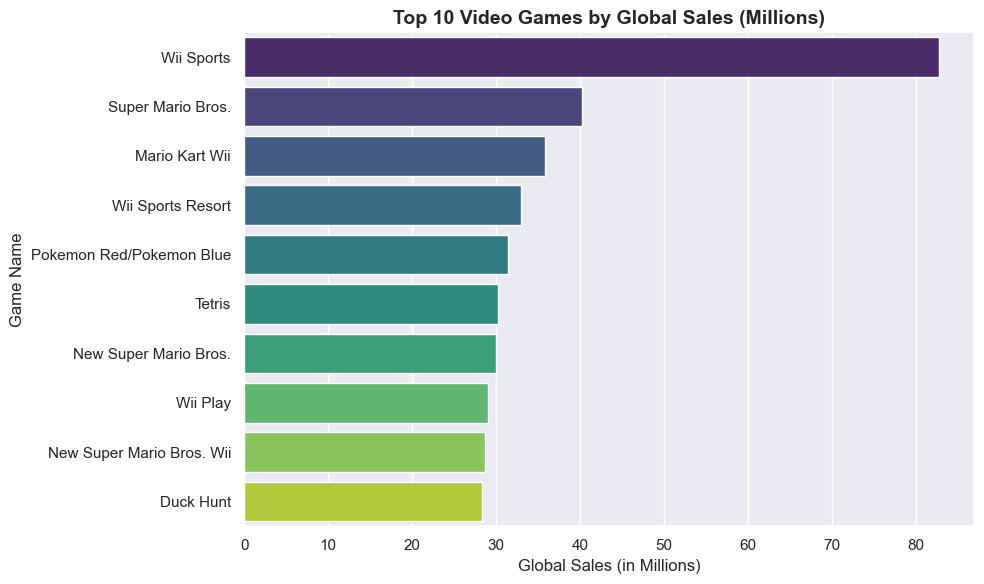

In [37]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 6))
top_10_games = df.sort_values(by='Global_Sales', ascending=False).head(10)
sns.barplot(x='Global_Sales', y='Name', data=top_10_games, palette='viridis', hue='Name', legend=False)
plt.title('Top 10 Video Games by Global Sales (Millions)', fontsize=14, fontweight='bold')
plt.xlabel('Global Sales (in Millions)')
plt.ylabel('Game Name')
plt.tight_layout()
plt.show()

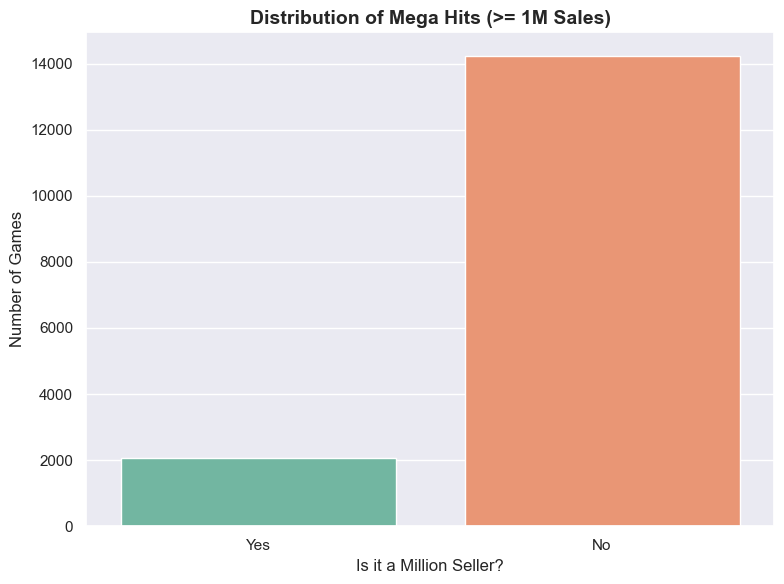

In [38]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Million_Seller', data=df, palette='Set2', hue='Million_Seller', legend=False)
plt.title('Distribution of Mega Hits (>= 1M Sales)', fontsize=14, fontweight='bold')
plt.xlabel('Is it a Million Seller?')
plt.ylabel('Number of Games')
plt.tight_layout()
plt.show()

In [39]:
df.to_csv("vgsales_cleaned_final.csv", index=False)